<a href="https://colab.research.google.com/github/Jana-Alothman/GP1/blob/main/Final_Datasets_Arabic_Readability_Classification_AraBERTv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Arabic Readability Classification on BAREC**

## Research-grounded comparison of three AraBERTv0.2 objectives

This notebook compares three training objectives on the same four-level BAREC data splits:

1. Weighted Cross-Entropy classification.
2. Rank-consistent CORAL ordinal classification.
3. Mean Squared Error (MSE) ordinal regression.

The checkpoint is `aubmindlab/bert-base-arabertv02`; therefore, the technically correct model name used throughout this notebook is **AraBERTv0.2**. The test split is reserved for a single final evaluation after selecting the model with validation QWK.


# **Data Collection**

**Dataset Source:**

In this project, the dataset used for Arabic readability assessment was obtained from BAREC Corpus v1.0 on Hugging Face.

---
**Research paper:**

A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.

---

**Data Fields:**
- ID: Unique sentence identifier.
- Sentence: The sentence text.
- Word_Count: Number of words in the sentence.
- Word: Simply tokenized and dediacritized sentences.
- Lex: Each word is replaced by its predicited lemma (dediacritized).
- D3Tok: We tokenize words into their base and clitics forms.
- D3Lex: We replace the base forms in D3Tok with the predicited lemmas.
- Readability_Level: The readability level in 19-levels scheme, ranging from 1-alif to 19-qaf.
- Readability_Level_19: The readability level in 19-levels scheme, ranging from 1 to 19.
- Readability_Level_7: The readability level in 7-levels scheme, ranging from 1 to 7.
- Readability_Level_5: The readability level in 5-levels scheme, ranging from 1 to 5.
- Readability_Level_3: The readability level in 3-levels scheme, ranging from 1 to 3.
- Annotator: The annotator ID (A1-A5 or IAA).
- Document: Source document file name.
- Source: Document source.
- Book: Book name.
- Author: Author name.
- Domain: Domain (Arts & Humanities, STEM or Social Sciences).
- Text_Class: Readership group (Foundational, Advanced or Specialized).

---
**Supported Tasks:**

The dataset supports multi-class readability classification in the following formats:

- 19 levels (default)
- 7 levels
- 5 levels
- 3 levels

---
**Data Splits:**
- The BAREC dataset has three splits: Train (80%), Dev (10%), and Test (10%).
- The splits are in the document level.
- The splits are balanced accross Readability Levels, Domains, and Text Classes.



In [6]:
# Install all dependencies required by the complete notebook.
!pip -q install -U datasets pandas transformers accelerate scikit-learn seaborn coral-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 115.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2026.6.0 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.


In [7]:
# Load the BAREC dataset and display dataset splits and columns.

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("CAMeL-Lab/BAREC-Corpus-v1.0")

# Load each split separately
train_df = dataset["train"].to_pandas()
dev_df = dataset["dev"].to_pandas()
test_df = dataset["test"].to_pandas()
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

print("\nDataset Columns:\n")
print(full_df.columns)

print("\nSample Data:\n")
full_df.head()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  if not is_google_colab() or is_colab_enterprise():


Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)

Dataset Columns:

Index(['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex',
       'Readability_Level', 'Readability_Level_19', 'Readability_Level_7',
       'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document',
       'Source', 'Book', 'Author', 'Domain', 'Text_Class'],
      dtype='str')

Sample Data:



,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,مجلة كل الأولاد وكل البنات,مجلة كل ولد كل بنت,مجلة كل ال+ أولاد و+ كل ال+ بنات,مجلة كل ال+ ولد و+ كل ال+ بنت,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,ماجد,ماجد,ماجد,ماجد,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,الأربعاء 21 يناير 1987,أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
3,10100290004,الموافق 21 جمادى الأول 1407هــ,6,الموافق 21 جمادى الأول 1407ه,موافق 21 جمادى أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,7-zay,7,2,1,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
4,10100290005,السنة الثامنة,2,السنة الثامنة,سنة ثامن,ال+ سنة ال+ ثامنة,ال+ سنة ال+ ثامن,5-ha,5,2,1,1,A4,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational


In [8]:
# Save the complete dataset as a CSV file.

full_df.to_csv("BAREC_full.csv", index=False)

In [9]:
# Create a filtered version containing selected columns only.

filtered_full_df = full_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_train_df = train_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_dev_df = dev_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_test_df = test_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_full_df.to_csv("BAREC_full_filtered.csv", index=False)
filtered_full_df.head()

,Word,Word_Count,Domain,Text_Class,Readability_Level_19,Readability_Level_5
0,مجلة كل الأولاد وكل البنات,5,Arts & Humanities,Foundational,7,1
1,ماجد,1,Arts & Humanities,Foundational,1,1
2,الأربعاء 21 يناير 1987,4,Arts & Humanities,Foundational,8,2
3,الموافق 21 جمادى الأول 1407ه,6,Arts & Humanities,Foundational,7,1
4,السنة الثامنة,2,Arts & Humanities,Foundational,5,1


**Feature Selection Justification**

Only the **Word** column was used as the input feature because this study aims to classify readability using textual information represented by TF-IDF features.

The remaining columns were excluded for the following reasons:

---

**Text Variations (Sentence, Lex, D3Tok, D3Lex)**

These columns are different linguistic transformations of the same sentence.

- They represent the same original text in different formats  

---

**Alternative Readability Levels (3, 7-level schemes)**

These columns represent the same target variable (readability) but on different scales.

- They contain overlapping information with the main target (19 & 5 -level scales)


---

**Metadata Columns (ID, Annotator, Document, Source, Book, Author)**

These columns are not useful for prediction.

- They are administrative or contextual only
- They do not contribute to readability prediction

---

**Final Selected Features**

The final dataset used for modeling includes:

- **Word** → main input text
- **Word_Count** → length-based feature
- **Domain** → topic/category information
- **Text_Class** → readership group
- **Readability_Level_19** → target label
- **Readability_Level_5** → target label

In [10]:
# Download both the full and filtered datasets.

from google.colab import files

#files.download("BAREC_full.csv")
#files.download("BAREC_full_filtered.csv")

# **Data Preprocessing**

In this stage, we perform preprocessing on the **filtered dataset** to ensure it is clean, consistent, and ready for machine learning.

## 1. Checking Missing Values

We first check whether the dataset contains any missing values.

Even if the dataset is clean, this step ensures there are no hidden nulls that could affect model training.

In [11]:
filtered_full_df.isnull().sum()

Word                    0
Word_Count              0
Domain                  0
Text_Class              0
Readability_Level_19    0
Readability_Level_5     0
dtype: int64

**Interpretation:** The dataset shows no missing values across all selected features, indicating that the data is complete and well-structured.

## 2. Checking Duplicate Rows

We check for duplicate rows to make sure the model does not learn repeated examples that could bias training.

In [12]:
beforeFull = filtered_full_df.duplicated().sum()
beforeTrain = filtered_train_df.duplicated().sum()
beforeDev = filtered_dev_df.duplicated().sum()
beforeTest = filtered_test_df.duplicated().sum()

print("Before dropping duplicates (Full) = " , beforeFull)
print("Before dropping duplicates (Train) = " , beforeTrain)
print("Before dropping duplicates (Dev) = " , beforeDev)
print("Before dropping duplicates (Test) = " , beforeTest)

Before dropping duplicates (Full) =  3542
Before dropping duplicates (Train) =  2670
Before dropping duplicates (Dev) =  195
Before dropping duplicates (Test) =  213


In [13]:
afterFull = filtered_full_df.drop_duplicates().duplicated().sum()
afterTrain = filtered_train_df.drop_duplicates().duplicated().sum()
afterDev = filtered_dev_df.drop_duplicates().duplicated().sum()
afterTest = filtered_test_df.drop_duplicates().duplicated().sum()

print("After dropping duplicates (Full) = " , afterFull)
print("After dropping duplicates (Train) = " , afterTrain)
print("After dropping duplicates (Dev) = " , afterDev)
print("After dropping duplicates (Test) = " , afterTest)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

After dropping duplicates (Full) =  0
After dropping duplicates (Train) =  0
After dropping duplicates (Dev) =  0
After dropping duplicates (Test) =  0
Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)


**Interpretation:** 3,542 duplicate rows were found in the dataset, indicating repeated samples. These duplicates were removed to prevent bias and ensure the model does not learn from repeated instances of the same data.

## 3. Checking Label Distribution

We analyze the distribution of the 19-level and 5-level readability classes to understand whether the dataset is balanced or imbalanced.

In [14]:
# Distribution for Readability Level 19
level_19_stats = (
    filtered_full_df["Readability_Level_19"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

level_19_stats["Percentage"] = (
    level_19_stats["Count"] / len(filtered_full_df) * 100
).round(2)

print("=== Readability Level 19 ===")
display(level_19_stats)


# Distribution for Readability Level 5
level_5_stats = (
    filtered_full_df["Readability_Level_5"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

level_5_stats["Percentage"] = (
    level_5_stats["Count"] / len(filtered_full_df) * 100
).round(2)

print("=== Readability Level 5 ===")
display(level_5_stats)

=== Readability Level 19 ===


,Count,Percentage
Readability_Level_19,,
1,409,0.59
2,437,0.63
3,1462,2.11
4,751,1.08
5,3443,4.96
6,1534,2.21
7,5438,7.83
8,5683,8.18
9,2023,2.91


=== Readability Level 5 ===


,Count,Percentage
Readability_Level_5,,
1,13474,19.40
2,22383,32.23
3,18510,26.66
4,13234,19.06
5,1840,2.65


In [15]:
filtered_full_df["Readability_Level_19"].value_counts().sort_index()

Readability_Level_19
1       409
2       437
3      1462
4       751
5      3443
6      1534
7      5438
8      5683
9      2023
10     9763
11     4914
12    14471
13     4039
14    10687
15     2547
16     1141
17      480
18      103
19      116
Name: count, dtype: int64

In [16]:
filtered_full_df["Readability_Level_5"].value_counts().sort_index()

Readability_Level_5
1    13474
2    22383
3    18510
4    13234
5     1840
Name: count, dtype: int64

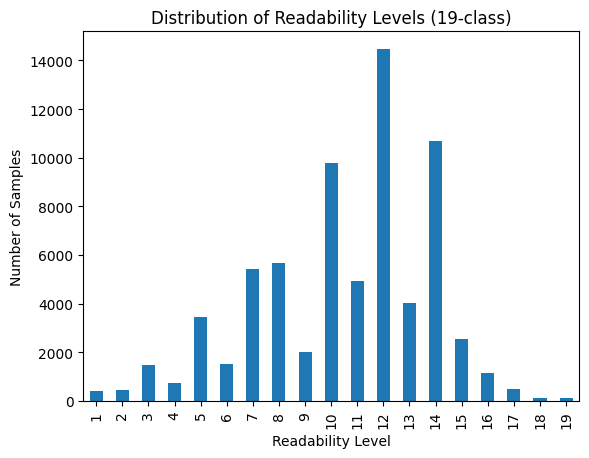

In [17]:
import matplotlib.pyplot as plt

full_df["Readability_Level_19"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (19-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

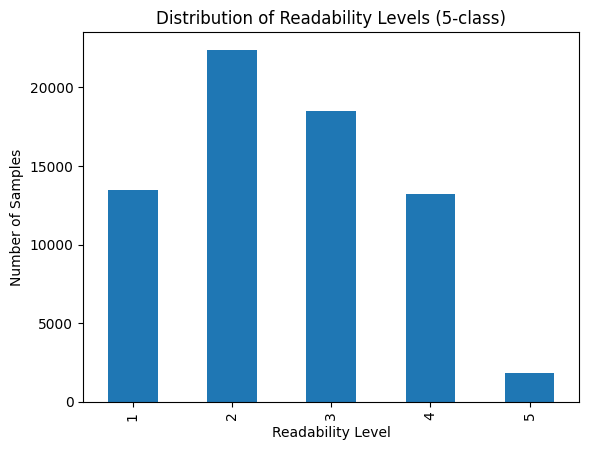

In [18]:
import matplotlib.pyplot as plt

full_df["Readability_Level_5"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (5-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

**Interpretation:** The dataset shows a clear class imbalance across the 19 and 5 readability levels. Some classes contain a significantly higher number of samples, while higher levels have very few instances. This imbalance may affect model performance and bias predictions toward majority classes.

##Handling Class Label Inbalance

### Step 1: Merge Readability Classes 4 and 5

The original `Readability_Level_5` contains five readability classes.

To reduce the class imbalance, Classes 4 and 5 will be merged into a single class. All samples originally labeled as Class 5 will be relabeled as Class 4.

As a result, the dataset will contain four readability classes: 1, 2, 3, and 4.

The original Class 5 label will no longer exist in the dataset.

In [19]:
# Create separate copies of the original BAREC splits
train_4 = filtered_train_df.copy()
val_4 = filtered_dev_df.copy()
test_4 = filtered_test_df.copy()

# Merge original Class 5 into Class 4 within each split
train_4["Readability_Level_5"] = train_4["Readability_Level_5"].replace(5, 4)
val_4["Readability_Level_5"] = val_4["Readability_Level_5"].replace(5, 4)
test_4["Readability_Level_5"] = test_4["Readability_Level_5"].replace(5, 4)

# Rename the target column
train_4 = train_4.rename(columns={"Readability_Level_5": "Readability_Level_4"})
val_4 = val_4.rename(columns={"Readability_Level_5": "Readability_Level_4"})
test_4 = test_4.rename(columns={"Readability_Level_5": "Readability_Level_4"})

# Display the original BAREC split sizes
print("=== Four-Class Dataset Sizes ===")
print(f"Train: {len(train_4)}")
print(f"Validation: {len(val_4)}")
print(f"Test: {len(test_4)}")

=== Four-Class Dataset Sizes ===
Train: 54845
Validation: 7310
Test: 7286


### Step 2: Verify the Four-Class Class Distribution

The class distribution is examined separately for the training, validation, and test sets after merging Classes 4 and 5. This step verifies that the four-class target contains only Classes 1, 2, 3, and 4.

In [20]:
# Check the four-class distribution in each split

print("=== Train Class Distribution ===")
print(train_4["Readability_Level_4"].value_counts().sort_index())

print("\n=== Validation Class Distribution ===")
print(val_4["Readability_Level_4"].value_counts().sort_index())

print("\n=== Test Class Distribution ===")
print(test_4["Readability_Level_4"].value_counts().sort_index())

=== Train Class Distribution ===
Readability_Level_4
1    10396
2    17908
3    14570
4    11971
Name: count, dtype: int64

=== Validation Class Distribution ===
Readability_Level_4
1    1679
2    2270
3    1840
4    1521
Name: count, dtype: int64

=== Test Class Distribution ===
Readability_Level_4
1    1399
2    2205
3    2100
4    1582
Name: count, dtype: int64


### Step 3: Calculate Class Percentages

The percentage of each readability class is calculated for the training, validation, and test sets. This provides a clearer view of the class distribution and the remaining class imbalance after merging Classes 4 and 5.

In [21]:
# Calculate class percentages for each split

for name, df in [
    ("Train", train_4),
    ("Validation", val_4),
    ("Test", test_4)
]:
    percentages = (
        df["Readability_Level_4"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    print(f"\n=== {name} Class Percentages ===")
    print(percentages.round(2))


=== Train Class Percentages ===
Readability_Level_4
1    18.96
2    32.65
3    26.57
4    21.83
Name: proportion, dtype: float64

=== Validation Class Percentages ===
Readability_Level_4
1    22.97
2    31.05
3    25.17
4    20.81
Name: proportion, dtype: float64

=== Test Class Percentages ===
Readability_Level_4
1    19.20
2    30.26
3    28.82
4    21.71
Name: proportion, dtype: float64


# Deep Learning Experiment

## Experimental protocol

All models use the official BAREC train/dev/test partitions and the same four-class mapping. Model development and checkpoint selection use only the training and validation partitions. The test partition is evaluated once after the validation winner is fixed. This prevents test-set information from influencing model selection.

The three objectives isolate the effect of the output formulation while holding the encoder, tokenization, data partitions, maximum sequence length, optimizer schedule, and evaluation metrics constant.


In [22]:
# Fix the Transformers installation

!pip install -q --upgrade --force-reinstall "transformers==4.46.3"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 5.0.1 requires fsspec[http]<=2026.6.0,>=2023.1.0, but you have fsspec 2026.9.0 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.5.3 which is incompatible.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2026.9.0 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
dask-cudf-cu12 26.

In [23]:
import inspect
import json
import math
import os
import random
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)
from transformers import (
    AutoConfig,
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from coral_pytorch.layers import CoralLayer
from coral_pytorch.losses import coral_loss

warnings.filterwarnings("ignore", category=FutureWarning)

MODEL_NAME = "aubmindlab/bert-base-arabertv02"
TEXT_COLUMN = "Word"
LABEL_COLUMN = "Readability_Level_4"
NUM_LABELS = 4
MAX_LENGTH = 128
SEED = 42
LEARNING_RATE = 2e-5
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
GRADIENT_ACCUMULATION_STEPS = 2
NUM_EPOCHS = 3
WEIGHT_DECAY = 0.01
WARMUP_FRACTION = 0.10

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if not torch.cuda.is_available():
    print("Warning: transformer fine-tuning on CPU will be very slow. Select a GPU runtime in Colab.")


Device: cuda


## Parameter justification

| Choice | Value | Academic or empirical basis |
|---|---:|---|
| Encoder | `bert-base-arabertv02` | Arabic pretrained transformer introduced by Antoun et al. [1]. The exact checkpoint name identifies AraBERTv0.2. |
| Learning rate | `2e-5` | One of the BERT fine-tuning rates evaluated by Devlin et al. [2] and used in the BAREC STBW system [7]. |
| Train batch size | `16` | Included in the BERT fine-tuning grid [2]. Gradient accumulation of 2 gives an effective batch size of 32 while fitting limited GPU memory. |
| Validation batch size | `32` | Inference does not store gradients; a larger batch reduces evaluation time when memory permits. It does not change learned parameters. |
| Epochs | `3` | A short BERT fine-tuning schedule consistent with Devlin et al. [2]. The best checkpoint is selected by validation QWK rather than the final epoch. |
| Weight decay | `0.01` | AdamW regularization value reported in the BERT training configuration [2]. |
| Warm-up | `10%` of update steps | Used by the BAREC STBW training procedure [7]; it stabilizes early optimization. |
| Dropout | `0.1` | Standard BERT hidden-state dropout [2]. |
| Maximum length | `128` tokens | Verified below against this project's training-token distribution. This is a data-dependent engineering choice, not a claimed universal optimum. |
| Random seed | `42` | Fixed solely for reproducibility; it is not claimed to be performance-optimal. |
| CORAL threshold | `0.5` | Converts each sigmoid boundary probability into a binary ordinal decision, following the CORAL formulation [4]. |
| Selection metric | Validation QWK | BAREC labels are ordered; quadratic weighting penalizes distant mistakes more strongly and is the official shared-task metric [3]. |

The numerical settings are fixed before test evaluation. A future hyperparameter study should tune them on the validation split only.


## 1. Final data preparation

Labels are converted from human-readable levels `1–4` to zero-based indices `0–3`, as required by PyTorch losses. No class is removed, and the official split identities are preserved.


In [24]:
def prepare_dl_split(df):
    prepared = df[[TEXT_COLUMN, LABEL_COLUMN]].dropna().copy()
    prepared[TEXT_COLUMN] = prepared[TEXT_COLUMN].astype(str).str.strip()
    prepared = prepared[prepared[TEXT_COLUMN].str.len() > 0].reset_index(drop=True)
    prepared["labels"] = prepared[LABEL_COLUMN].astype(int) - 1
    if not prepared["labels"].between(0, NUM_LABELS - 1).all():
        raise ValueError("Labels must map to the zero-based range 0..3.")
    return prepared[[TEXT_COLUMN, "labels"]]

train_dl = prepare_dl_split(train_4)
val_dl = prepare_dl_split(val_4)
test_dl = prepare_dl_split(test_4)

print("Train:", train_dl.shape)
print("Validation:", val_dl.shape)
print("Test:", test_dl.shape)
display(train_dl.head())


Train: (54845, 2)
Validation: (7310, 2)
Test: (7286, 2)


,Word,labels
0,مجلة كل الأولاد وكل البنات,0
1,ماجد,0
2,الأربعاء 21 يناير 1987,1
3,الموافق 21 جمادى الأول 1407ه,0
4,السنة الثامنة,0


## 2. Tokenization and sequence-length verification

The tokenizer must match the pretrained checkpoint. Length statistics are computed from the training split only. The reported percentage above 128 tokens quantifies the truncation introduced by `MAX_LENGTH=128` and allows this value to be defended empirically.


In [25]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_token_ids = tokenizer(
    train_dl[TEXT_COLUMN].tolist(),
    add_special_tokens=True,
    truncation=False,
)["input_ids"]
train_lengths = np.asarray([len(ids) for ids in train_token_ids])

length_summary = pd.Series(train_lengths).describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
).to_frame("tokens")
display(length_summary)
print(f"Training examples longer than {MAX_LENGTH}: {(train_lengths > MAX_LENGTH).mean():.2%}")

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        max_length=MAX_LENGTH,
    )

def to_tokenized_dataset(df):
    dataset = Dataset.from_pandas(df, preserve_index=False)
    return dataset.map(
        tokenize_batch,
        batched=True,
        remove_columns=[TEXT_COLUMN],
        desc="Tokenizing",
    )

train_ds = to_tokenized_dataset(train_dl)
val_ds = to_tokenized_dataset(val_dl)
test_ds = to_tokenized_dataset(test_dl)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

,tokens
count,54845.000000
mean,19.439876
std,14.044356
min,3.000000
50%,16.000000
90%,38.000000
95%,46.000000
99%,66.000000
max,227.000000


Training examples longer than 128: 0.03%


Tokenizing:   0%|          | 0/54845 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/7310 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/7286 [00:00<?, ? examples/s]

## 3. Evaluation metrics

Accuracy and Macro-F1 measure exact classification performance. QWK, MAE, and RMSE use the ordering of readability levels. RMSE penalizes large level errors more strongly than MAE. `within_one` reports the proportion of predictions no more than one level away from the reference.


In [26]:
def ordinal_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "within_one": np.mean(np.abs(y_true - y_pred) <= 1),
    }

def unpack_logits(predictions):
    return predictions[0] if isinstance(predictions, tuple) else predictions

def compute_cross_entropy_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(unpack_logits(logits), axis=-1)
    return ordinal_metrics(labels, predictions)

def coral_logits_to_labels(logits):
    probabilities = torch.sigmoid(torch.as_tensor(logits)).cpu().numpy()
    return (probabilities > 0.5).sum(axis=1).astype(int)

def compute_coral_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = coral_logits_to_labels(unpack_logits(logits))
    return ordinal_metrics(labels, predictions)

def regression_outputs_to_labels(outputs):
    raw_scores = np.asarray(outputs).reshape(-1)
    return np.clip(np.rint(raw_scores), 0, NUM_LABELS - 1).astype(int)

def compute_mse_metrics(eval_pred):
    outputs, labels = eval_pred
    raw_scores = np.asarray(unpack_logits(outputs)).reshape(-1)
    predictions = regression_outputs_to_labels(raw_scores)
    metrics = ordinal_metrics(labels, predictions)
    metrics["raw_mae"] = mean_absolute_error(labels, raw_scores)
    metrics["raw_rmse"] = np.sqrt(mean_squared_error(labels, raw_scores))
    return metrics


## 4. Shared training configuration

All three models receive the same update budget and checkpoint-selection rule. `save_total_limit=1` retains only the best checkpoint to reduce storage. Mixed precision is enabled only when a CUDA GPU supports it.


In [27]:
updates_per_epoch = math.ceil(
    len(train_ds) / (TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)
)
total_update_steps = updates_per_epoch * NUM_EPOCHS
warmup_steps = round(WARMUP_FRACTION * total_update_steps)

def make_training_args(output_dir):
    parameters = inspect.signature(TrainingArguments.__init__).parameters
    kwargs = dict(
        output_dir=output_dir,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_steps=warmup_steps,
        save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="qwk",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=SEED,
        data_seed=SEED,
    )
    if "eval_strategy" in parameters:
        kwargs["eval_strategy"] = "epoch"
    else:
        kwargs["evaluation_strategy"] = "epoch"
    return TrainingArguments(**kwargs)

print("Updates per epoch:", updates_per_epoch)
print("Total update steps:", total_update_steps)
print("Warm-up steps:", warmup_steps)


Updates per epoch: 1714
Total update steps: 5142
Warm-up steps: 514


## 5. Model 1 — AraBERTv0.2 with Weighted Cross-Entropy

Cross-entropy is the standard objective for mutually exclusive text classes and was evaluated with AraBERT in the original BAREC study [5]. It is used here as a **nominal classification comparator**, not described as the official BAREC baseline. Inverse-frequency weights are computed from the training split only to reduce the dominance of frequent classes. This weighting is a project adaptation to the observed imbalance; it is not claimed to reproduce the unweighted BAREC configuration.


In [34]:
class_counts = np.bincount(train_dl["labels"], minlength=NUM_LABELS)
class_weights = len(train_dl) / (NUM_LABELS * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

display(pd.DataFrame({
    "level": np.arange(1, NUM_LABELS + 1),
    "training_count": class_counts,
    "cross_entropy_weight": class_weights,
}))

class WeightedCrossEntropyTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_function = nn.CrossEntropyLoss(
            weight=class_weights_tensor.to(outputs.logits.device)
        )
        loss = loss_function(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

set_seed(SEED)
cross_entropy_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

cross_entropy_trainer = WeightedCrossEntropyTrainer(
    model=cross_entropy_model,
    args=make_training_args("./results_weighted_cross_entropy"),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_cross_entropy_metrics,
)

cross_entropy_trainer.train()
cross_entropy_validation_metrics = cross_entropy_trainer.evaluate()
cross_entropy_validation_metrics


,level,training_count,cross_entropy_weight
0,1,10396,1.318897
1,2,17908,0.765649
2,3,14570,0.941060
3,4,11971,1.145372


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Qwk,Mae,Rmse,Within One
1,0.852400,0.724292,0.687962,0.673791,0.755326,0.399590,0.767054,0.919289
2,0.612600,0.687219,0.719425,0.713015,0.783221,0.352668,0.712791,0.933516


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Qwk,Mae,Rmse,Within One
1,0.852400,0.724292,0.687962,0.673791,0.755326,0.399590,0.767054,0.919289
2,0.612600,0.687219,0.719425,0.713015,0.783221,0.352668,0.712791,0.933516
3,0.486800,0.728124,0.718468,0.714577,0.782656,0.350479,0.705848,0.935978


{'eval_loss': 0.6872190833091736,
 'eval_accuracy': 0.7194254445964432,
 'eval_macro_f1': 0.7130146108903355,
 'eval_qwk': 0.7832211104685924,
 'eval_mae': 0.3526675786593707,
 'eval_rmse': 0.7127910882095234,
 'eval_within_one': 0.933515731874145,
 'eval_runtime': 5.9306,
 'eval_samples_per_second': 1232.588,
 'eval_steps_per_second': 38.613,
 'epoch': 3.0}

### Model 1 interpretation rule

The primary result is `eval_qwk`; `eval_macro_f1` verifies that performance is not driven only by frequent classes. A lower `eval_mae` and `eval_rmse` indicates smaller ordinal errors. Because weighted cross-entropy treats the four output classes as separate categories, it does not explicitly encode their order.


## 6. Model 2 — AraBERTv0.2 with rank-consistent CORAL

CORAL reformulates a four-level problem into three cumulative boundary decisions and constrains their biases to produce rank-consistent outputs [4]. The implementation below uses the official `coral-pytorch` `CoralLayer` and `coral_loss`, rather than a CORAL-inspired approximation. Its relevance to Arabic readability is supported by the ZAI BAREC system, which combined AraBERT with CORAL [6].


In [35]:
class AraBERTCoral(nn.Module):
    def __init__(self, model_name, num_labels, dropout_probability=0.1):
        super().__init__()
        self.num_labels = num_labels
        self.config = AutoConfig.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name, config=self.config)
        self.dropout = nn.Dropout(dropout_probability)
        self.coral_layer = CoralLayer(
            size_in=self.config.hidden_size,
            num_classes=num_labels,
        )

    @staticmethod
    def labels_to_levels(labels, num_labels):
        boundaries = torch.arange(
            num_labels - 1,
            device=labels.device,
        ).unsqueeze(0)
        return (labels.unsqueeze(1) > boundaries).float()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None):
        encoder_inputs = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
        }
        if token_type_ids is not None:
            encoder_inputs["token_type_ids"] = token_type_ids

        encoder_outputs = self.encoder(**encoder_inputs)
        cls_representation = self.dropout(encoder_outputs.last_hidden_state[:, 0, :])
        logits = self.coral_layer(cls_representation)

        loss = None
        if labels is not None:
            levels = self.labels_to_levels(labels, self.num_labels)
            loss = coral_loss(logits, levels)

        return SequenceClassifierOutput(loss=loss, logits=logits)

set_seed(SEED)
coral_model = AraBERTCoral(MODEL_NAME, NUM_LABELS)

coral_trainer = Trainer(
    model=coral_model,
    args=make_training_args("./results_coral"),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_coral_metrics,
)

coral_trainer.train()
coral_validation_metrics = coral_trainer.evaluate()
coral_validation_metrics


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Qwk,Mae,Rmse,Within One
1,1.427100,1.362378,0.496443,0.451217,0.706949,0.621204,0.934884,0.891108
2,1.265400,1.356212,0.517373,0.473101,0.725127,0.586457,0.901208,0.905198
3,1.179800,1.405897,0.494802,0.449563,0.712340,0.616279,0.925767,0.898222


{'eval_loss': 1.35621178150177,
 'eval_accuracy': 0.5173734610123119,
 'eval_macro_f1': 0.4731006855689438,
 'eval_qwk': 0.7251269501483515,
 'eval_mae': 0.5864569083447333,
 'eval_rmse': 0.9012075801940301,
 'eval_within_one': 0.9051983584131327,
 'eval_runtime': 6.0292,
 'eval_samples_per_second': 1212.429,
 'eval_steps_per_second': 37.982,
 'epoch': 3.0}

### Model 2 interpretation rule

Each logit represents whether the predicted readability level exceeds one ordered boundary. The final label equals the number of boundary probabilities above 0.5. CORAL is favored only if its validation QWK exceeds the alternatives; its ordinal design alone does not guarantee superior empirical performance.


## 7. Model 3 — AraBERTv0.2 with MSE ordinal regression

MSE represents readability as one continuous score, directly penalizing the squared distance between predicted and reference levels. The original BAREC study reported strong QWK from regression-oriented training [5], and the STBW BAREC system used an MSE phase before SoftQWK optimization [7]. This notebook evaluates the simpler MSE formulation as a distinct third comparator; it is not presented as a reproduction of the complete STBW method.


In [29]:
class MSERegressionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        scores = outputs.logits.squeeze(-1)
        loss = nn.MSELoss()(scores, labels)
        return (loss, outputs) if return_outputs else loss

set_seed(SEED)
mse_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    problem_type="regression",
)

mse_trainer = MSERegressionTrainer(
    model=mse_model,
    args=make_training_args("./results_mse_regression"),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_mse_metrics,
)

mse_trainer.train()
mse_validation_metrics = mse_trainer.evaluate()
mse_validation_metrics


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Qwk,Mae,Rmse,Within One,Raw Mae,Raw Rmse
1,0.558400,0.464220,0.630643,0.630130,0.763055,0.423256,0.733226,0.949384,0.482736,0.681337
2,0.336100,0.378022,0.673187,0.676747,0.793705,0.365800,0.668215,0.962380,0.430124,0.614835
3,0.261100,0.392965,0.677565,0.676289,0.787869,0.367579,0.679281,0.956635,0.416984,0.626869


{'eval_loss': 0.37802186608314514,
 'eval_accuracy': 0.673187414500684,
 'eval_macro_f1': 0.676746939071868,
 'eval_qwk': 0.7937049570644914,
 'eval_mae': 0.3658002735978112,
 'eval_rmse': 0.6682152556676454,
 'eval_within_one': 0.9623803009575923,
 'eval_raw_mae': 0.4301242232322693,
 'eval_raw_rmse': 0.6148348282938639,
 'eval_runtime': 5.6206,
 'eval_samples_per_second': 1300.579,
 'eval_steps_per_second': 40.743,
 'epoch': 3.0}

### Model 3 interpretation rule

The raw scalar is rounded to the nearest integer and clipped to `0–3` for classification metrics. `eval_raw_rmse` evaluates the unrounded continuous predictions, whereas `eval_rmse` evaluates the final discrete levels. The model is selected using discrete validation QWK to maintain one comparison rule across all three objectives.


## 8. Validation comparison and model selection

The selected model is the one with the highest validation QWK. Accuracy is not used for selection because it ignores the distance between ordered levels. The test set remains untouched until this decision is complete.


In [ ]:
def validation_row(name, metrics):
    return {
        "model": name,
        "accuracy": metrics["eval_accuracy"],
        "macro_f1": metrics["eval_macro_f1"],
        "qwk": metrics["eval_qwk"],
        "mae": metrics["eval_mae"],
        "rmse": metrics["eval_rmse"],
        "within_one": metrics["eval_within_one"],
    }

validation_comparison = pd.DataFrame([
    validation_row("Weighted Cross-Entropy", cross_entropy_validation_metrics),
    validation_row("CORAL", coral_validation_metrics),
    validation_row("MSE Regression", mse_validation_metrics),
]).sort_values("qwk", ascending=False).reset_index(drop=True)

display(validation_comparison.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "qwk": "{:.4f}",
    "mae": "{:.4f}",
    "rmse": "{:.4f}",
    "within_one": "{:.4f}",
}))

best_model_name = validation_comparison.loc[0, "model"]
print("Selected model by validation QWK:", best_model_name)


## 9. Single final test evaluation

This cell must be run only after all validation results are available. The resulting test metrics estimate the performance of the already selected pipeline and must not be used to change the model choice or hyperparameters.


In [37]:
model_registry = {
    "Weighted Cross-Entropy": (cross_entropy_trainer, compute_cross_entropy_metrics),
    "CORAL": (coral_trainer, compute_coral_metrics),
    "MSE Regression": (mse_trainer, compute_mse_metrics),
}

best_trainer, _ = model_registry[best_model_name]
test_output = best_trainer.predict(test_ds)
test_metrics = test_output.metrics

if best_model_name == "Weighted Cross-Entropy":
    test_predictions = np.argmax(unpack_logits(test_output.predictions), axis=-1)
elif best_model_name == "CORAL":
    test_predictions = coral_logits_to_labels(unpack_logits(test_output.predictions))
else:
    test_predictions = regression_outputs_to_labels(unpack_logits(test_output.predictions))

test_labels = np.asarray(test_output.label_ids, dtype=int)

test_summary = pd.DataFrame([{
    "selected_model": best_model_name,
    "accuracy": test_metrics["test_accuracy"],
    "macro_f1": test_metrics["test_macro_f1"],
    "qwk": test_metrics["test_qwk"],
    "mae": test_metrics["test_mae"],
    "rmse": test_metrics["test_rmse"],
    "within_one": test_metrics["test_within_one"],
}])
display(test_summary)


,selected_model,accuracy,macro_f1,qwk,mae,rmse,within_one
0,MSE Regression,0.678287,0.690921,0.794353,0.35479,0.651336,0.96857


## 10. Confusion matrix and class-wise report

Rows represent reference levels and columns represent predicted levels. Concentration near the diagonal indicates ordinally close predictions. Off-diagonal cells separated by two or three levels identify the most consequential errors and are reflected more strongly in RMSE and QWK.


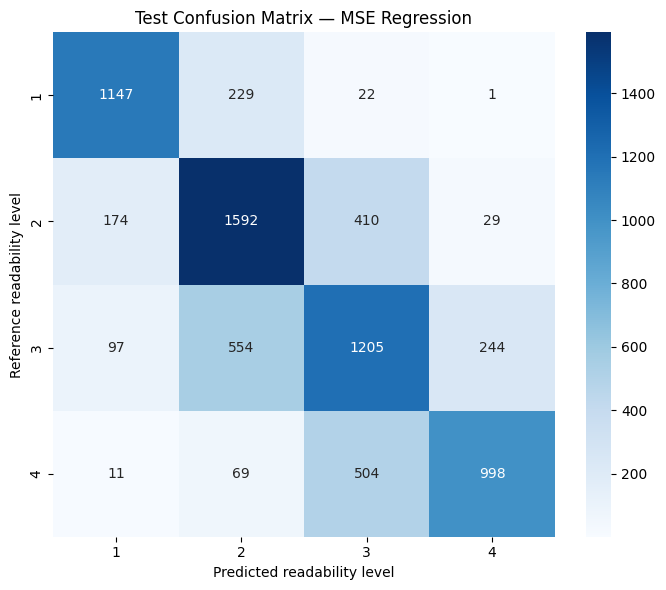

              precision    recall  f1-score   support

     Level 1     0.8027    0.8199    0.8112      1399
     Level 2     0.6514    0.7220    0.6849      2205
     Level 3     0.5628    0.5738    0.5683      2100
     Level 4     0.7846    0.6308    0.6994      1582

    accuracy                         0.6783      7286
   macro avg     0.7004    0.6866    0.6909      7286
weighted avg     0.6838    0.6783    0.6787      7286



In [38]:
human_labels = np.arange(1, NUM_LABELS + 1)
cm = confusion_matrix(test_labels + 1, test_predictions + 1, labels=human_labels)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=human_labels,
    yticklabels=human_labels,
)
plt.title(f"Test Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted readability level")
plt.ylabel("Reference readability level")
plt.tight_layout()
plt.show()

print(classification_report(
    test_labels + 1,
    test_predictions + 1,
    labels=human_labels,
    target_names=[f"Level {level}" for level in human_labels],
    digits=4,
    zero_division=0,
))


## 11. Save the selected model and experiment metadata

The tokenizer, selected weights, validation table, test metrics, and experimental constants are stored together. Custom CORAL weights are saved as a PyTorch state dictionary because its head is not a standard Hugging Face sequence-classification head.


In [39]:
SAVE_DIR = "./best_barec_readability_model"
os.makedirs(SAVE_DIR, exist_ok=True)
tokenizer.save_pretrained(SAVE_DIR)

if best_model_name == "CORAL":
    torch.save(best_trainer.model.state_dict(), os.path.join(SAVE_DIR, "coral_model_state.pt"))
    saved_format = "AraBERTCoral state_dict"
else:
    best_trainer.model.save_pretrained(SAVE_DIR)
    saved_format = "Hugging Face save_pretrained"

def json_safe(value):
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, dict):
        return {key: json_safe(item) for key, item in value.items()}
    if isinstance(value, list):
        return [json_safe(item) for item in value]
    return value

metadata = {
    "selected_model": best_model_name,
    "selection_metric": "validation_qwk",
    "checkpoint": MODEL_NAME,
    "saved_format": saved_format,
    "label_mapping": {"0": 1, "1": 2, "2": 3, "3": 4},
    "parameters": {
        "max_length": MAX_LENGTH,
        "seed": SEED,
        "learning_rate": LEARNING_RATE,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "effective_train_batch_size": TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS,
        "epochs": NUM_EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "warmup_fraction": WARMUP_FRACTION,
    },
    "validation_comparison": validation_comparison.to_dict(orient="records"),
    "test_metrics": test_metrics,
}

with open(os.path.join(SAVE_DIR, "experiment_metadata.json"), "w", encoding="utf-8") as file:
    json.dump(json_safe(metadata), file, ensure_ascii=False, indent=2)

print("Saved to:", SAVE_DIR)


Saved to: ./best_barec_readability_model


# Findings reporting template

Report the validation comparison first and identify the selected model solely by the highest validation QWK. Then report its test Accuracy, Macro-F1, QWK, MAE, RMSE, and within-one accuracy. Discuss whether most errors are adjacent levels using the confusion matrix. Do not claim superiority over published BAREC systems unless the corpus version, label scheme, preprocessing, split protocol, and evaluation metric are identical.

If the result is lower than published BAREC results, plausible experimental differences include the four-class label merge, the selected AraBERTv0.2 checkpoint, weighted rather than unweighted cross-entropy, sequence truncation, hyperparameter budget, and differences between this objective and a paper's complete training pipeline. These are methodological differences, not evidence that the implementation failed.


#**Classification with WikiLarge Dataset**

In [ ]:
import pandas as pd
import torch
import torch.nn.functional as F
import numpy as np
import json
import os

###**Step 1: Data Loading**

The cleaned Arabic WikiLarge dataset was loaded, consisting of 50 original (complex) sentences, each paired with 8 human-written simplified versions (Simple_1 through Simple_8). This dataset was previously verified to contain no missing values and no duplicate rows.

In [ ]:
# STEP 1: Load the WikiLarge clean data
# --------------------------------------------------------from google.colab import files
uploaded = files.upload()  # ارفعي Arabic_WikiLarge_Clean.csv

df = pd.read_csv("Arabic_WikiLarge_Clean.csv")
print("Shape:", df.shape)

VERSION_COLUMNS = ["Original"] + [f"Simple_{i}" for i in range(1, 9)]

###**Step 2: Reshaping the Data (Wide to Long)**

Since each row originally contained 9 separate text columns (the original sentence plus its 8 simplifications), the data was reshaped into a long format in which each text instance occupies its own row, tagged with a pair_id (identifying which of the 50 sentences it belongs to) and a version label (Original, Simple_1, ..., Simple_8). This transformation produced 450 rows (50 sentences × 9 versions) and allowed all texts to be classified in a single batched inference pass rather than nine separate ones.

In [ ]:
# STEP 2: Reshape wide -> long
# --------------------------------------------------------
df_long = df.reset_index().melt(
    id_vars=["index"],
    value_vars=VERSION_COLUMNS,
    var_name="version",
    value_name="text",
)
df_long = df_long.rename(columns={"index": "pair_id"})
print("Long shape (should be 50 x 9 = 450 rows):", df_long.shape)

###**Step 3: Loading the Trained Classifier**

The classifier used in this experiment is the best-performing model identified in the deep learning phase: an AraBERTv0.2 encoder fine-tuned with an MSE (Mean Squared Error) regression objective on the four-level BAREC readability task (Classes 4 and 5 merged). Among the three objectives compared during training (Weighted Cross-Entropy, rank-consistent CORAL, and MSE Regression), the MSE Regression model achieved the highest validation Quadratic Weighted Kappa (QWK) and was therefore selected as the final model, achieving a test QWK of 0.797, an accuracy of 67.97%, and a within-one-level accuracy of 97.09%. Unlike the earlier softmax-based classifier, this model outputs a single continuous score directly, rather than a probability distribution over discrete classes.

In [ ]:
# STEP 3: Load the saved MSE Regression model
# --------------------------------------------------------
# If your saved model is inside Google Drive or was re-uploaded,
# adjust SAVE_DIR accordingly. This assumes the same Colab
# session/runtime where the training notebook saved it, OR that
# you've uploaded the saved folder as a zip and extracted it here.

from transformers import AutoTokenizer, AutoModelForSequenceClassification

SAVE_DIR = "./best_barec_readability_model"

with open(os.path.join(SAVE_DIR, "experiment_metadata.json"), encoding="utf-8") as f:
    metadata = json.load(f)

print("Selected model:", metadata["selected_model"])
assert metadata["selected_model"] == "MSE Regression", (
    "This script assumes the MSE Regression model won. "
    "If a different model was selected, tell me and I'll adjust the loading code."
)

MAX_LENGTH = metadata["parameters"]["max_length"]

tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)  # num_labels=1, regression head

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()


###**Step 4: Running Inference on All 450 Texts**

Each of the 450 texts (the original sentences and their eight simplified counterparts) was passed through the trained regression model. Two outputs were recorded per text: (1) a continuous score, converted to the human-readable 1–4 scale by adding 1 to the model's zero-based output, representing the model's raw, unconstrained estimate of readability; and (2) a discrete predicted level, obtained by rounding the raw score to the nearest integer and clipping it to the valid range before converting to the 1–4 scale, following the same interpretation rule defined in the original training notebook. The discrete level was used as the primary basis for all subsequent comparisons, as it directly reflects the model's final classification decision and inherently respects the natural boundaries of the four-level scale.

In [ ]:
# STEP 4: Run regression inference on all 450 texts
# --------------------------------------------------------

def classify_texts_regression(texts, batch_size=16):
    """
    Returns:
        continuous_levels: raw predicted score, converted to the
            human 1-4 scale (score_zero_based + 1). NOT clipped —
            this is the model's true unconstrained output.
        discrete_levels: round(score) clipped to [0,3], +1 -> 1-4.
            This matches the notebook's own official interpretation
            rule for the final predicted level.
    """
    continuous_levels = []
    discrete_levels = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch, truncation=True, max_length=MAX_LENGTH,
            padding=True, return_tensors="pt",
        ).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits.squeeze(-1)  # raw continuous score, zero-based (0-3 range target)
        continuous_levels.extend((logits + 1).cpu().tolist())  # convert to human 1-4 scale

        clipped = torch.clamp(torch.round(logits), min=0, max=3)
        discrete_levels.extend((clipped + 1).cpu().long().tolist())  # human 1-4 scale
    return continuous_levels, discrete_levels

texts = df_long["text"].astype(str).tolist()
continuous_levels, discrete_levels = classify_texts_regression(texts)

print("Continuous level range (unclipped, informational only):",
      min(continuous_levels), "to", max(continuous_levels))
print("Discrete level range (should be 1 to 4):",
      min(discrete_levels), "to", max(discrete_levels))

df_long["continuous_level"] = [round(x, 3) for x in continuous_levels]
df_long["predicted_level"] = discrete_levels

print(df_long.head(12))

###**Step 5: Reshaping Results Back to Wide Format**

The predicted levels (both continuous and discrete) were reshaped back into the original wide format, producing one row per sentence pair with 18 additional columns: a discrete _Level and a continuous _RawScore for the original sentence and each of its eight simplified versions. This final table was exported for reference and further analysis.

In [ ]:
# STEP 5: Reshape back to wide format
# --------------------------------------------------------
df_discrete_wide = df_long.pivot(index="pair_id", columns="version", values="predicted_level")
df_discrete_wide = df_discrete_wide[VERSION_COLUMNS]
df_discrete_wide.columns = [f"{c}_Level" for c in df_discrete_wide.columns]

df_continuous_wide = df_long.pivot(index="pair_id", columns="version", values="continuous_level")
df_continuous_wide = df_continuous_wide[VERSION_COLUMNS]
df_continuous_wide.columns = [f"{c}_RawScore" for c in df_continuous_wide.columns]

final_df = pd.concat(
    [df, df_discrete_wide.reset_index(drop=True), df_continuous_wide.reset_index(drop=True)],
    axis=1,
)
final_df.to_csv("wikilarge_mse_model_levels.csv", index=False, encoding="utf-8-sig")

print("Saved: wikilarge_mse_model_levels.csv")
print(final_df[[c for c in final_df.columns if "_Level" in c]].head())

###**Step 6: Per-Version Comparison (Reduced / Same / Increased)**

For each of the 8 simplified versions, the predicted discrete level was compared against the predicted level of the corresponding original sentence across all 50 sentence pairs. Each comparison was categorized as Reduced (the simplified version received a lower predicted level, indicating the model perceived it as easier), Same (an identical predicted level, indicating no perceived change in difficulty), or Increased (a higher predicted level, indicating the model perceived it as more difficult than the original). Results are reported in part/whole (fraction) format for transparency.

In [ ]:
# STEP 6: Per-sentence direction (Reduced / Same / Increased),
#         each shown as (count / total) — fraction format
# --------------------------------------------------------
orig_level = final_df["Original_Level"]

print("\n=== Per-version comparison (part/whole format) ===")
summary_rows = []
for i in range(1, 9):
    col = f"Simple_{i}_Level"
    reduced = int((final_df[col] < orig_level).sum())
    same = int((final_df[col] == orig_level).sum())
    increased = int((final_df[col] > orig_level).sum())
    print(f"Simple_{i}: Reduced={reduced}/50, Same={same}/50, Increased={increased}/50")
    summary_rows.append({"Version": f"Simple_{i}", "Reduced": reduced, "Same": same, "Increased": increased})

summary_df = pd.DataFrame(summary_rows)
totals = {
    "Version": "TOTAL",
    "Reduced": summary_df["Reduced"].sum(),
    "Same": summary_df["Same"].sum(),
    "Increased": summary_df["Increased"].sum(),
}
summary_df = pd.concat([summary_df, pd.DataFrame([totals])], ignore_index=True)
for idx, row in summary_df.iterrows():
    total = 400 if row["Version"] == "TOTAL" else 50
    summary_df.loc[idx, "Reduced_frac"] = f'{row["Reduced"]}/{total}'
    summary_df.loc[idx, "Same_frac"] = f'{row["Same"]}/{total}'
    summary_df.loc[idx, "Increased_frac"] = f'{row["Increased"]}/{total}'

display(summary_df)

###**Step 7: Corrected Breakdown by Original Readability Level**

Because the classifier operates on a bounded four-level scale (1 to 4), two outcomes are structurally impossible regardless of the data: a sentence whose original predicted level is already 1 cannot be classified as "Reduced" (no level exists below 1), and a sentence whose original predicted level is already 4 cannot be classified as "Increased" (no level exists above 4). To avoid misrepresenting these structurally impossible outcomes as a value of zero (which would incorrectly imply the outcome was possible but simply did not occur), the results were instead broken down separately for each original readability level (1 through 4), with a dash ("–") explicitly marking the cells corresponding to these two impossible cases. This produces a methodologically correct distribution of results, in which every reported percentage is computed only over the comparisons for which that outcome was actually achievable.

In [ ]:
# STEP 7: CORRECTED breakdown by Original Level (1-4)
#         "-" marks structurally impossible directions:
#         Level 1 can never show "Reduced" (nothing below 1)
#         Level 4 can never show "Increased" (nothing above 4)
# --------------------------------------------------------
by_level_rows = []
simple_cols = [f"Simple_{i}_Level" for i in range(1, 9)]

for level in [1, 2, 3, 4]:
    mask = orig_level == level
    n_sentences = int(mask.sum())
    n_comparisons = n_sentences * 8  # 8 simplified versions per sentence

    reduced_count = 0
    same_count = 0
    increased_count = 0
    for col in simple_cols:
        sub = final_df.loc[mask, col]
        sub_orig = orig_level.loc[mask]
        reduced_count += int((sub < sub_orig).sum())
        same_count += int((sub == sub_orig).sum())
        increased_count += int((sub > sub_orig).sum())

    row = {
        "Original_Level": level,
        "N_Sentences": n_sentences,
        "N_Comparisons": n_comparisons,
        "Reduced": "-" if level == 1 else f"{reduced_count}/{n_comparisons}",
        "Same": f"{same_count}/{n_comparisons}" if n_comparisons > 0 else "-",
        "Increased": "-" if level == 4 else f"{increased_count}/{n_comparisons}",
    }
    by_level_rows.append(row)

by_level_df = pd.DataFrame(by_level_rows)
print("\n=== Breakdown by Original Readability Level (corrected boundaries) ===")
display(by_level_df)

by_level_df.to_csv("level_breakdown_corrected.csv", index=False)
summary_df.to_csv("version_summary_fractions.csv", index=False)

from google.colab import files as colab_files
colab_files.download("wikilarge_mse_model_levels.csv")
colab_files.download("level_breakdown_corrected.csv")
colab_files.download("version_summary_fractions.csv")


###Conclusion:

Using the best-performing readability classifier (AraBERTv0.2 with MSE Regression, test QWK = 0.797), only 11.0% of the 400 human-written simplifications were assigned a lower predicted readability level than their corresponding original sentence, while the large majority (82.0%) received an identical predicted level, and a further 7.0% were, counter-intuitively, assigned a higher predicted level than the original.

This pattern is not uniform across difficulty levels. When the results are broken down by the original sentence's predicted level, a clear trend emerges: sentences at higher original readability levels are substantially more likely to be recognized as successfully simplified. Only 0.8% of simplifications of Level-2 sentences were classified as easier, compared to 10.9% for Level-3 sentences and 26.1% for Level-4 sentences — a more than 30-fold increase in the model's sensitivity to simplification between the easiest and hardest original levels. This is consistent with the fact that lower-level sentences have a narrower range of levels below them into which a prediction can fall, while higher-level sentences have more room to be classified as easier.

The single Level-1 sentence in the sample (N=1) is reported separately for transparency, but its result (5/8 comparisons increased) should not be treated as statistically meaningful given the extremely small sample size at that level.

Overall, these results suggest that while the classifier does register genuine improvement from simplification — particularly for more difficult source sentences — the majority of human simplifications in this dataset do not shift the predicted readability level at all, and a non-trivial minority are perceived as making the text harder rather than easier. This motivates further investigation into whether this reflects a limitation of the classifier's sensitivity, a domain mismatch between the BAREC training data and the machine-translated WikiLarge sentences, or genuine cases where the human simplification did not measurably reduce linguistic complexity as captured by the model.

# References

[1] Antoun, W., Baly, F., & Hajj, H. (2020). **AraBERT: Transformer-based Model for Arabic Language Understanding.** OSACT 2020. https://aclanthology.org/2020.osact-1.2/

[2] Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). **BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.** NAACL-HLT 2019. https://aclanthology.org/N19-1423/

[3] Elmadani, K. N., Alhafni, B., Taha, H., & Habash, N. (2025). **BAREC Shared Task 2025 on Arabic Readability Assessment.** ArabicNLP 2025. https://aclanthology.org/2025.arabicnlp-sharedtasks.34/

[4] Cao, W., Mirjalili, V., & Raschka, S. (2020). **Rank-consistent Ordinal Regression for Neural Networks with Application to Age Estimation.** Pattern Recognition Letters, 140, 325–331. https://doi.org/10.1016/j.patrec.2020.11.008

[5] Elmadani, K. N., Habash, N., & Taha-Thomure, H. (2025). **A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.** Findings of ACL 2025. https://aclanthology.org/2025.findings-acl.842/

[6] Nazzal, A. M. (2025). **ZAI at BAREC Shared Task 2025: AraBERT CORAL for Fine Grained Arabic Readability.** ArabicNLP 2025 Shared Tasks. https://aclanthology.org/2025.arabicnlp-sharedtasks.37/

[7] Trigui, S. (2025). **STBW at BAREC Shared Task 2025: AraBERT-v2 with MSE-SoftQWK Loss for Sentence-Level Arabic Readability.** ArabicNLP 2025 Shared Tasks. https://aclanthology.org/2025.arabicnlp-sharedtasks.50/


##EW-SEW Readability Classification

#### Step 1: Load EW-SEW dataset


In [ ]:

from google.colab import files
uploaded = files.upload()

ew_df = pd.read_csv("Arabic_EW_SEW_Clean.csv")

print("Shape:", ew_df.shape)
print("\nSplit distribution:")
print(ew_df["Split"].value_counts())

display(ew_df.head())

#### Step 2: Convert Normal and Simple sentences to long format


In [ ]:

ew_long = ew_df.melt(
    id_vars=["Pair_ID", "Split"],
    value_vars=["Normal", "Simple"],
    var_name="Text_Type",
    value_name="text"
)

print("Total pairs:", len(ew_df))
print("Total texts for classification:", len(ew_long))

display(ew_long.head(10))

#### Step 3: Classify EW-SEW using the trained MSE Regression model


In [ ]:

texts = ew_long["text"].astype(str).tolist()

# The function returns:
# 1. Continuous regression scores
# 2. Predicted readability levels
continuous_predictions, predicted_levels = classify_texts_regression(texts)

# Add predictions to the dataframe
ew_long["continuous_level"] = continuous_predictions
ew_long["predicted_level"] = predicted_levels

print("Total classified texts:", len(ew_long))

display(
    ew_long[
        ["Pair_ID", "Split", "Text_Type",
         "text", "continuous_level", "predicted_level"]
    ].head(10)
)

#### Step 4: Reshape predictions back to Normal-Simple pairs


In [ ]:

normal_results = ew_long[
    ew_long["Text_Type"] == "Normal"
][["Pair_ID", "continuous_level", "predicted_level"]].copy()

normal_results = normal_results.rename(columns={
    "continuous_level": "Normal_Continuous_Level",
    "predicted_level": "Normal_Level"
})

simple_results = ew_long[
    ew_long["Text_Type"] == "Simple"
][["Pair_ID", "continuous_level", "predicted_level"]].copy()

simple_results = simple_results.rename(columns={
    "continuous_level": "Simple_Continuous_Level",
    "predicted_level": "Simple_Level"
})

# Merge with the original dataset
final_ew = ew_df.merge(normal_results, on="Pair_ID", how="left")
final_ew = final_ew.merge(simple_results, on="Pair_ID", how="left")

print("Total pairs:", len(final_ew))

display(final_ew.head(10))

#### Step 5: Analyze readability level changes


In [ ]:
final_ew["Level_Change"] = final_ew.apply(
    lambda row:
        "Reduced" if row["Simple_Level"] < row["Normal_Level"]
        else "Same" if row["Simple_Level"] == row["Normal_Level"]
        else "Increased",
    axis=1
)

# Overall results
change_counts = final_ew["Level_Change"].value_counts()
change_percent = final_ew["Level_Change"].value_counts(normalize=True) * 100

print("Overall readability change:")
for category in ["Reduced", "Same", "Increased"]:
    print(
        f"{category}: {change_counts.get(category, 0)} "
        f"({change_percent.get(category, 0):.2f}%)"
    )

#### Step 6: Analyze readability changes by dataset split


In [ ]:

split_analysis = pd.crosstab(
    final_ew["Split"],
    final_ew["Level_Change"]
)

split_percent = pd.crosstab(
    final_ew["Split"],
    final_ew["Level_Change"],
    normalize="index"
) * 100

print("Counts by split:")
display(split_analysis)

print("\nPercentages by split:")
display(split_percent.round(2))

#### Step 7: Final validation before saving


In [ ]:

print("Total pairs:", len(final_ew))
print("Unique Pair IDs:", final_ew["Pair_ID"].nunique())

print("\nMissing values:")
print(
    final_ew[
        ["Normal_Level", "Simple_Level",
         "Normal_Continuous_Level", "Simple_Continuous_Level"]
    ].isnull().sum()
)

print("\nNormal level distribution:")
print(final_ew["Normal_Level"].value_counts().sort_index())

print("\nSimple level distribution:")
print(final_ew["Simple_Level"].value_counts().sort_index())

print("\nNormal level range:",
      final_ew["Normal_Level"].min(),
      "to",
      final_ew["Normal_Level"].max())

print("Simple level range:",
      final_ew["Simple_Level"].min(),
      "to",
      final_ew["Simple_Level"].max())

In [ ]:

output_columns = [
    "Pair_ID",
    "Split",
    "Normal",
    "Simple",
    "Normal_Continuous_Level",
    "Normal_Level",
    "Simple_Continuous_Level",
    "Simple_Level",
    "Level_Change"
]

final_ew[output_columns].to_csv(
    "Arabic_EW_SEW_MSE_Model_Levels.csv",
    index=False,
    encoding="utf-8-sig"
)

print("File saved successfully!")
print("Shape:", final_ew[output_columns].shape)

In [ ]:

level_counts = pd.DataFrame({
    "Normal": final_ew["Normal_Level"].value_counts().sort_index(),
    "Simple": final_ew["Simple_Level"].value_counts().sort_index()
})

level_counts.index.name = "Level"

print("Number of texts in each readability level:")
display(level_counts)

###Step 8: Classification Breakdown

In [ ]:

# Table 1: Level distribution
level_summary = pd.DataFrame({
    "Normal": [
        (final_ew["Normal_Level"] == level).sum()
        for level in range(1, 5)
    ],
    "Simple": [
        (final_ew["Simple_Level"] == level).sum()
        for level in range(1, 5)
    ]
}, index=["Level 1", "Level 2", "Level 3", "Level 4"])

print("EW-SEW Level Distribution")
display(level_summary)


# Table 2: Normal → Simple level transitions
transition = pd.crosstab(
    final_ew["Normal_Level"],
    final_ew["Simple_Level"]
)

transition = transition.reindex(
    index=[1, 2, 3, 4],
    columns=[1, 2, 3, 4],
    fill_value=0
)

transition.index = [
    "Normal L1",
    "Normal L2",
    "Normal L3",
    "Normal L4"
]

transition.columns = [
    "Simple L1",
    "Simple L2",
    "Simple L3",
    "Simple L4"
]

print("\nNormal → Simple Level Breakdown")
display(transition)

#**BAREC Readability Model Evaluation on SAMER Dataset**

## Experiment Approach

This experiment evaluates the generalization of the pretrained Baraq readability classification model on the SAMER dataset.


### Simplification Effect Evaluation

If SAMER provides original and simplified versions of the same text, the Baraq model will be applied to both versions. Their predicted readability levels will then be compared to determine whether the model detects the expected reduction in readability difficulty after simplification.


In [40]:
# Install and import the required libraries

!pip install -q transformers datasets scikit-learn pandas numpy scipy

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2026.6.0 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.


In [41]:
# Import the required libraries

import pandas as pd
import numpy as np

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix
)

from scipy.stats import spearmanr

## Step 1: Load the SAMER Dataset

The SAMER dataset is loaded from its TSV files. The dataset contains parallel texts at three readability levels: L5 (original), L4 (simplified), and L3 (further simplified). The data will be inspected before applying the Baraq readability model.

In [42]:
# Step 1: Load the SAMER dataset

import pandas as pd

# Load the dataset splits
train_df = pd.read_csv("/content/train.tsv", sep="\t")
dev_df = pd.read_csv("/content/dev.tsv", sep="\t")
test_df = pd.read_csv("/content/test.tsv", sep="\t")

# Display dataset sizes
print("Train:", train_df.shape)
print("Dev:", dev_df.shape)
print("Test:", test_df.shape)

# Display column names
print("\nColumns:")
print(train_df.columns.tolist())

# Display a few samples
display(train_df.head())

Train: (14343, 6)
Dev: (2983, 6)
Test: (3277, 6)

Columns:
['Novel', 'Chapter', 'L5', 'L4', 'L3', 'Line']


,Novel,Chapter,L5,L4,L3,Line
0,0,2.0,الفصل الثاني,الفصل الثاني,الفصل الثاني,0
1,0,2.0,«وكان صباح..,«وكان صباح..,«وكان صباح..,1
2,0,2.0,يوما واحدا»,يوما واحدا»,يوما واحدا»,1
3,0,2.0,قضى فتانا إبراهيم — وهذا اسمه — ليلة هادئة عمي...,قضى فتانا إبراهيم — وهذا اسمه — ليلة هادئة عمي...,قضى فتانا إبراهيم — وهذا اسمه — ليلة هادئة عمي...,2
4,0,2.0,ينحدر على أحد جانبيه نهر جائش،,ينحدر على أحد جانبيه نهر هائج،,ينحدر على أحد جانبيه نهر هائج،,2


## Step 2: Prepare Original and Simplified Text Pairs

The test split is used for evaluation. Each SAMER instance contains an original text at L5 and two simplified versions at L4 and L3.

For each instance, the original L5 text will be paired with its corresponding L4 and L3 simplified versions to evaluate whether the Baraq model detects the expected readability reduction.

In [43]:
# Step 2: Prepare the SAMER test pairs

# Use the test split for evaluation
samer_test = test_df.copy()

# Keep only the columns needed for the experiment
samer_test = samer_test[["Novel", "Chapter", "Line", "L5", "L4", "L3"]]

# Display the first few pairs
display(samer_test.head())

print("Number of test instances:", len(samer_test))

,Novel,Chapter,Line,L5,L4,L3
0,0,7.2,0,ولكنها تحركت!,ولكنها تحركت!,ولكنها تحركت!
1,0,7.2,0,إما لأنها أحست به وإما لأن الوقفة أتعبتها أو أ...,إما لأنها أحست به وإما لأن الوقفة أتعبتها أو أ...,إما لأنها أحست به وإما لأن الوقفة أتعبتها أو أ...
2,0,7.2,0,فرأته فصبغ الدم وجهها وارتدت،,فرأته فصبغ الدم وجهها وارتدت،,فرأته فصبغ الدم وجهها وارتدت،
3,0,7.2,0,ولكنها لم تتجهم له وقالت وفي عينها نظرة عتب ور...,ولكنها لم تعبس له وقالت وفي عينها نظرة عتب ورض...,ولكنها لم تعبس له وقالت وفي عينها نظرة عتب ورض...
4,0,7.2,0,ألك هنا كثير؟,ألك هنا كثير؟,ألك هنا كثير؟


Number of test instances: 3277


## Step 3: Prepare Texts for Baraq

The L5, L4, and L3 texts are prepared as separate inputs for the Baraq readability model. L5 represents the original text, while L4 and L3 represent progressively simplified versions.

In [44]:
# Step 3: Extract the original and simplified texts

original_texts = samer_test["L5"].astype(str).tolist()
simplified_l4 = samer_test["L4"].astype(str).tolist()
simplified_l3 = samer_test["L3"].astype(str).tolist()

print("Original L5 texts:", len(original_texts))
print("Simplified L4 texts:", len(simplified_l4))
print("Simplified L3 texts:", len(simplified_l3))

Original L5 texts: 3277
Simplified L4 texts: 3277
Simplified L3 texts: 3277


## Step 4: Load the Baraq Readability Model

The pretrained Baraq readability model and its tokenizer are loaded to predict the readability level of the SAMER texts.

In [45]:
# Step 4: Load the saved Baraq MSE Regression model

import os
import json
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Path to the saved Baraq model
SAVE_DIR = "./best_barec_readability_model"

# Load experiment metadata
with open(
    os.path.join(SAVE_DIR, "experiment_metadata.json"),
    encoding="utf-8"
) as f:
    metadata = json.load(f)

print("Selected model:", metadata["selected_model"])

# Make sure the selected model is MSE Regression
assert metadata["selected_model"] == "MSE Regression"

# Load the same maximum sequence length used during training
MAX_LENGTH = metadata["parameters"]["max_length"]

# Load tokenizer and trained model
tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)

# Use GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)
model.eval()

print("Device:", device)
print("Max length:", MAX_LENGTH)

Selected model: MSE Regression
Device: cuda
Max length: 128


## Step 5: Run Baraq Inference on SAMER

The Baraq MSE regression model is applied to the L5, L4, and L3 texts. For each text, the model produces a continuous readability score and a discrete readability level from 1 to 4.

The discrete predicted level will be used to compare the original and simplified versions.

In [46]:
# Step 5: Run Baraq inference on SAMER

def classify_texts_regression(texts, batch_size=16):
    continuous_levels = []
    discrete_levels = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i + batch_size]

        # Tokenize the text using Baraq's tokenizer
        inputs = tokenizer(
            batch,
            truncation=True,
            max_length=MAX_LENGTH,
            padding=True,
            return_tensors="pt"
        ).to(device)

        # Run the model without calculating gradients
        with torch.no_grad():
            logits = model(**inputs).logits.squeeze(-1)

        # Continuous score on the 1-4 human-readable scale
        continuous_levels.extend(
            (logits + 1).cpu().tolist()
        )

        # Convert the regression output to a discrete level (1-4)
        clipped = torch.clamp(
            torch.round(logits),
            min=0,
            max=3
        )

        discrete_levels.extend(
            (clipped + 1).cpu().long().tolist()
        )

    return continuous_levels, discrete_levels


# Run the model on the three SAMER levels
l5_continuous, l5_predicted = classify_texts_regression(original_texts)
l4_continuous, l4_predicted = classify_texts_regression(simplified_l4)
l3_continuous, l3_predicted = classify_texts_regression(simplified_l3)

print("L5 predictions:", len(l5_predicted))
print("L4 predictions:", len(l4_predicted))
print("L3 predictions:", len(l3_predicted))

L5 predictions: 3277
L4 predictions: 3277
L3 predictions: 3277


## Step 6: Organize the Model Predictions

The predictions from the Baraq model are combined with the corresponding SAMER texts. Each row represents one text fragment and contains the original L5 text, its L4 and L3 simplified versions, and the predicted readability level for each version.

In [47]:
# Step 6: Create a results DataFrame

results_df = samer_test.copy()

# Add Baraq predictions for each readability level
results_df["L5_prediction"] = l5_predicted
results_df["L4_prediction"] = l4_predicted
results_df["L3_prediction"] = l3_predicted

# Add continuous regression scores
results_df["L5_score"] = l5_continuous
results_df["L4_score"] = l4_continuous
results_df["L3_score"] = l3_continuous

# Display the results
display(
    results_df[
        [
            "L5", "L5_prediction",
            "L4", "L4_prediction",
            "L3", "L3_prediction"
        ]
    ].head(10)
)

,L5,L5_prediction,L4,L4_prediction,L3,L3_prediction
0,ولكنها تحركت!,2,ولكنها تحركت!,2,ولكنها تحركت!,2
1,إما لأنها أحست به وإما لأن الوقفة أتعبتها أو أ...,2,إما لأنها أحست به وإما لأن الوقفة أتعبتها أو أ...,2,إما لأنها أحست به وإما لأن الوقفة أتعبتها أو أ...,2
2,فرأته فصبغ الدم وجهها وارتدت،,2,فرأته فصبغ الدم وجهها وارتدت،,2,فرأته فصبغ الدم وجهها وارتدت،,2
3,ولكنها لم تتجهم له وقالت وفي عينها نظرة عتب ور...,3,ولكنها لم تعبس له وقالت وفي عينها نظرة عتب ورض...,3,ولكنها لم تعبس له وقالت وفي عينها نظرة عتب ورض...,3
4,ألك هنا كثير؟,1,ألك هنا كثير؟,1,ألك هنا كثير؟,1
5,فدنا منها خطوة: «لا!,2,فدنا منها خطوة: «لا!,2,فدنا منها خطوة: «لا!,2
6,مع الأسف»!,2,مع الأسف»!,2,مع الأسف»!,2
7,فلم ترده عن الدنو ولم تحاول أن تتحول عن مكانها...,2,فلم ترده عن الدنو ولم تحاول أن تتحول عن مكانها...,2,فلم ترده عن القرب ولم تحاول أن تتحول عن مكانها...,2
8,وقالت وكلتا يديها وراءها على الحاجز وصدرها بثد...,2,وقالت وكلتا يديها وراءها على الحاجز وصدرها بثد...,2,وقالت وكلتا يديها وراءها على الحاجز وصدرها بثد...,2
9,فقال برقة،,2,فقال برقة،,2,فقال برقة،,2


## Step 7: Evaluate the Effect of Simplification

The predicted readability levels of the original L5 texts are compared with their corresponding L4 and L3 simplified versions.

Each comparison is categorized as:
- Reduced: the simplified text receives a lower predicted readability level.
- Same: the predicted readability level remains unchanged.
- Increased: the simplified text receives a higher predicted readability level.

In [48]:
# Step 7: Compare the original and simplified predictions

def compare_levels(original, simplified):
    if simplified < original:
        return "Reduced"
    elif simplified == original:
        return "Same"
    else:
        return "Increased"


# Compare L5 with L4
results_df["L5_to_L4"] = [
    compare_levels(l5, l4)
    for l5, l4 in zip(
        results_df["L5_prediction"],
        results_df["L4_prediction"]
    )
]

# Compare L5 with L3
results_df["L5_to_L3"] = [
    compare_levels(l5, l3)
    for l5, l3 in zip(
        results_df["L5_prediction"],
        results_df["L3_prediction"]
    )
]

# Display a sample
display(
    results_df[
        [
            "L5_prediction",
            "L4_prediction",
            "L5_to_L4",
            "L3_prediction",
            "L5_to_L3"
        ]
    ].head(10)
)

,L5_prediction,L4_prediction,L5_to_L4,L3_prediction,L5_to_L3
0,2,2,Same,2,Same
1,2,2,Same,2,Same
2,2,2,Same,2,Same
3,3,3,Same,3,Same
4,1,1,Same,1,Same
5,2,2,Same,2,Same
6,2,2,Same,2,Same
7,2,2,Same,2,Same
8,2,2,Same,2,Same
9,2,2,Same,2,Same


## Step 8: Calculate Overall Simplification Results

The proportions of Reduced, Same, and Increased readability predictions are calculated for both L4 and L3 compared with the original L5 texts.

In [49]:
# Step 8: Calculate the distribution of simplification effects

# Calculate counts
l5_l4_counts = results_df["L5_to_L4"].value_counts()
l5_l3_counts = results_df["L5_to_L3"].value_counts()

# Calculate percentages
l5_l4_percentages = (
    results_df["L5_to_L4"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

l5_l3_percentages = (
    results_df["L5_to_L3"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("L5 → L4 Results:")
print(l5_l4_percentages)

print("\nL5 → L3 Results:")
print(l5_l3_percentages)

L5 → L4 Results:
L5_to_L4
Same         94.96
Reduced       4.64
Increased     0.40
Name: proportion, dtype: float64

L5 → L3 Results:
L5_to_L3
Same         89.29
Reduced       9.77
Increased     0.95
Name: proportion, dtype: float64


## Step 9: Summarize the Results

The results are summarized to compare the effect of the two simplification levels on the readability predictions produced by the Baraq model.

In [50]:
# Step 9: Create a summary table

summary_df = pd.DataFrame({
    "Comparison": ["L5 → L4", "L5 → L3"],
    "Reduced (%)": [
        l5_l4_percentages.get("Reduced", 0),
        l5_l3_percentages.get("Reduced", 0)
    ],
    "Same (%)": [
        l5_l4_percentages.get("Same", 0),
        l5_l3_percentages.get("Same", 0)
    ],
    "Increased (%)": [
        l5_l4_percentages.get("Increased", 0),
        l5_l3_percentages.get("Increased", 0)
    ]
})

display(summary_df)

,Comparison,Reduced (%),Same (%),Increased (%)
0,L5 → L4,4.64,94.96,0.40
1,L5 → L3,9.77,89.29,0.95


## Step 10: Analysis of Results

The Baraq model showed a higher rate of readability reduction for L3 compared with L4.

For L5 → L4, 4.64% of the samples received a lower predicted readability level, while 94.96% remained at the same level and 0.40% increased.

For L5 → L3, 9.77% of the samples received a lower predicted readability level, while 89.29% remained at the same level and 0.95% increased.

The higher reduction observed for L3 is consistent with its greater simplification relative to L5. However, the high proportion of unchanged predictions indicates that the discrete four-level Baraq classifier does not detect a readability-level change for most SAMER samples.

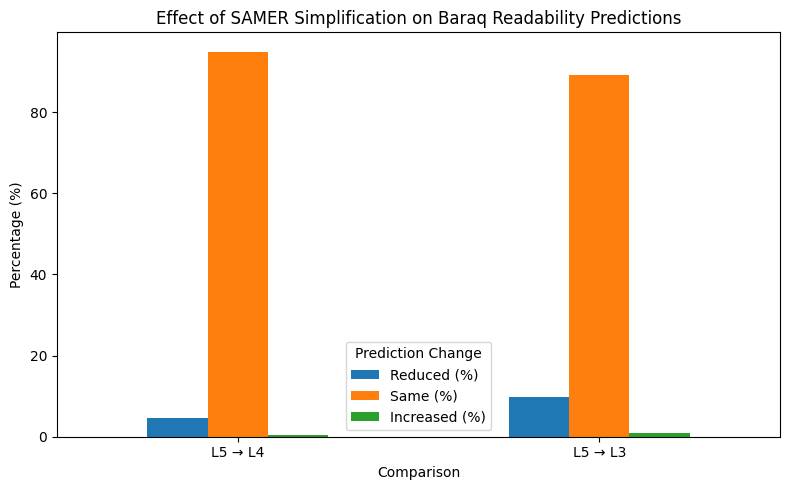

In [51]:
# Step 10: Visualize the simplification effect

import matplotlib.pyplot as plt

summary_plot = summary_df.set_index("Comparison")

summary_plot[["Reduced (%)", "Same (%)", "Increased (%)"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Effect of SAMER Simplification on Baraq Readability Predictions")
plt.xlabel("Comparison")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Prediction Change")
plt.tight_layout()
plt.show()

## Step 11: Analyze Continuous Readability Scores

The continuous readability scores are analyzed to detect changes that may not appear after converting the regression outputs into four discrete readability levels.

In [52]:
# Step 11: Analyze continuous score changes

# Calculate the change in readability score after simplification
results_df["L5_to_L4_score_change"] = (
    results_df["L4_score"] - results_df["L5_score"]
)

results_df["L5_to_L3_score_change"] = (
    results_df["L3_score"] - results_df["L5_score"]
)

# Calculate the average score change
mean_l4_change = results_df["L5_to_L4_score_change"].mean()
mean_l3_change = results_df["L5_to_L3_score_change"].mean()

print(f"Average L5 → L4 score change: {mean_l4_change:.4f}")
print(f"Average L5 → L3 score change: {mean_l3_change:.4f}")

Average L5 → L4 score change: -0.0402
Average L5 → L3 score change: -0.0878


## Step 12: Analyze the Direction of Continuous Score Changes

The continuous score changes are categorized into decreased, unchanged, and increased readability scores. This provides a more sensitive analysis than the discrete four-level predictions.

In [53]:
# Step 12: Categorize continuous score changes

def categorize_score_change(change, tolerance=1e-6):
    if change < -tolerance:
        return "Decreased"
    elif change > tolerance:
        return "Increased"
    else:
        return "Unchanged"


# Categorize L5 → L4 changes
results_df["L5_to_L4_score_direction"] = (
    results_df["L5_to_L4_score_change"]
    .apply(categorize_score_change)
)

# Categorize L5 → L3 changes
results_df["L5_to_L3_score_direction"] = (
    results_df["L5_to_L3_score_change"]
    .apply(categorize_score_change)
)

# Calculate percentages
l4_score_direction = (
    results_df["L5_to_L4_score_direction"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

l3_score_direction = (
    results_df["L5_to_L3_score_direction"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Continuous score: L5 → L4")
print(l4_score_direction)

print("\nContinuous score: L5 → L3")
print(l3_score_direction)

Continuous score: L5 → L4
L5_to_L4_score_direction
Unchanged    76.29
Decreased    20.05
Increased     3.66
Name: proportion, dtype: float64

Continuous score: L5 → L3
L5_to_L3_score_direction
Unchanged    48.79
Decreased    41.65
Increased     9.55
Name: proportion, dtype: float64


## Step 13: Compare Average Continuous Readability Scores

The average continuous readability score is calculated separately for L5, L4, and L3 to examine whether the model reflects the expected decrease in readability difficulty across the SAMER simplification levels.

In [54]:
# Step 13: Calculate the average continuous score for each SAMER level

average_scores = pd.DataFrame({
    "SAMER Level": ["L5 (Original)", "L4 (Simplified)", "L3 (More Simplified)"],
    "Average Baraq Score": [
        results_df["L5_score"].mean(),
        results_df["L4_score"].mean(),
        results_df["L3_score"].mean()
    ]
})

average_scores["Average Baraq Score"] = (
    average_scores["Average Baraq Score"].round(4)
)

display(average_scores)

,SAMER Level,Average Baraq Score
0,L5 (Original),2.2903
1,L4 (Simplified),2.2502
2,L3 (More Simplified),2.2025


## **Results**

## 1. Discrete Readability-Level Predictions

The Baraq model was applied to the three SAMER readability levels: L5 (original), L4 (simplified), and L3 (more simplified). The predicted readability levels were compared between the original and simplified versions.

| Comparison | Reduced (%) | Same (%) | Increased (%) |
|------------|------------:|---------:|--------------:|
| L5 → L4 | 4.64 | 94.96 | 0.40 |
| L5 → L3 | 9.77 | 89.29 | 0.95 |

The results show that most samples remained within the same discrete Baraq readability level after simplification. However, the proportion of reduced predictions increased from 4.64% for L5 → L4 to 9.77% for L5 → L3.

This indicates that the more strongly simplified L3 texts produced a larger proportion of lower predicted readability levels compared with the original L5 texts.

## 2. Continuous Readability-Score Analysis

Since the Baraq model produces a continuous regression score before converting it into one of four discrete readability levels, the continuous scores were also analyzed to capture smaller changes that may not be reflected in the discrete predictions.

The average change in the continuous score was:

| Comparison | Average Score Change |
|------------|---------------------:|
| L5 → L4 | -0.0402 |
| L5 → L3 | -0.0878 |

Both values are negative, indicating that the average predicted readability score decreased after simplification. The decrease was larger for L5 → L3 than for L5 → L4.

## 3. Direction of Continuous Score Changes

The direction of the continuous score change was further analyzed for each sample.

| Comparison | Decreased (%) | Unchanged (%) | Increased (%) |
|------------|--------------:|--------------:|--------------:|
| L5 → L4 | 20.05 | 76.29 | 3.66 |
| L5 → L3 | 41.65 | 48.79 | 9.55 |

The continuous scores show a clearer effect of simplification than the discrete predictions. In particular, the proportion of samples with a decreased readability score increased from 20.05% for L5 → L4 to 41.65% for L5 → L3.

This suggests that the continuous regression output captures smaller changes in readability that may remain within the same discrete four-level category.

## 4. Average Readability Scores Across SAMER Levels

The average Baraq score was calculated independently for each SAMER level.

| SAMER Level | Description | Average Baraq Score |
|-------------|-------------|--------------------:|
| L5 | Original | 2.2903 |
| L4 | Simplified | 2.2502 |
| L3 | More Simplified | 2.2025 |

The average scores show a consistent downward trend:

**L5 → L4 → L3**

with the average score decreasing from **2.2903** for the original L5 texts to **2.2502** for L4 and **2.2025** for L3.

## 5. Overall Interpretation

Overall, the Baraq model produced progressively lower average readability scores as the SAMER texts became more simplified. The continuous scores therefore provide stronger evidence of a gradual readability change than the discrete four-level predictions.

The high proportion of unchanged discrete predictions does not necessarily indicate that the model failed to detect simplification. Instead, smaller changes in the continuous regression scores can remain within the same discrete readability level after rounding.

The results also show that the effect becomes more noticeable for L3, which represents a greater degree of simplification than L4. The average Baraq score decreased from **2.2903 (L5)** to **2.2502 (L4)** and then to **2.2025 (L3)**.

Therefore, the SAMER experiment demonstrates that the Baraq model can reflect the direction of readability change across progressively simplified texts, particularly when its continuous regression scores are considered alongside the discrete readability levels.